In [1]:
import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import kagglehub

c:\Users\USER PC\OneDrive\Desktop\computer vision\project_2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER PC\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random seed is set at", SEED)

Random seed is set at 42


In [4]:
DATA_DIR = "data"

print("contents:", sorted(os.listdir(DATA_DIR)))

contents: ['Cat', 'Dog']


In [5]:
class_names = sorted(name for name in os.listdir(DATA_DIR)
                     if os.path.isdir(os.path.join(DATA_DIR, name)))

class_names

['Cat', 'Dog']

In [6]:
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
class_to_index

{'Cat': 0, 'Dog': 1}

In [7]:
MAX_IMAGES_PER_CLASS = 500  # set to None to use every image
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

def collect_image_paths(data_dir, class_names, class_to_index, max_per_class=MAX_IMAGES_PER_CLASS):
    """Build parallel lists of image paths and integer labels, optionally sampled."""
    rng = np.random.default_rng(SEED)
    image_paths = []
    labels = []
    empty_files = []

    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        file_names = sorted(
            name for name in os.listdir(class_dir)
            if name.lower().endswith(IMAGE_EXTENSIONS)
        )

        # A zero-byte file is never a valid image, and checking the size is cheap enough
        # to do for every file in the dataset rather than only the ones we sample.
        usable_paths = []
        for file_name in file_names:
            path = os.path.join(class_dir, file_name)
            if os.path.getsize(path) == 0:
                empty_files.append(path)
            else:
                usable_paths.append(path)

        if max_per_class is not None and len(usable_paths) > max_per_class:
            chosen = rng.choice(len(usable_paths), size=max_per_class, replace=False)
            usable_paths = [usable_paths[i] for i in sorted(chosen)]

        image_paths.extend(usable_paths)
        labels.extend([class_to_index[class_name]] * len(usable_paths))

    return image_paths, labels, empty_files

# # Call function and print results
image_paths, labels, empty_files = collect_image_paths(
    DATA_DIR, class_names, class_to_index, max_per_class=MAX_IMAGES_PER_CLASS
)

print("Images collected :", len(image_paths))
print("Zero-byte files :", len(empty_files))
for path in empty_files[:5]:
    print("  skipped:", path)
print()
print("First example path :", image_paths[0])
print("First example label:", labels[0], "->", class_names[labels[0]])

Images collected : 1000
Zero-byte files : 0

First example path : data\Cat\10054.jpg
First example label: 0 -> Cat


### Data Cleaning: Drop Corrupted Files
This step verifies that every image can be properly decoded using OpenCV and removes any broken files.

In [8]:
def keep_readable_images(image_paths, labels):
    """Drop any file that OpenCV cannot actually decode."""
    good_paths = []
    good_labels = []
    broken_paths = []
    
    for path, label in zip(image_paths, labels):
        if cv2.imread(path) is None:
            broken_paths.append(path)
        else:
            good_paths.append(path)
            good_labels.append(label)
            
    return good_paths, good_labels, broken_paths

image_paths, labels, broken_paths = keep_readable_images(image_paths, labels)

print("Usable images :", len(image_paths))
print("Broken images :", len(broken_paths))
for path in broken_paths[:5]:
    print("  dropped:", path)

Usable images : 1000
Broken images : 0


In [9]:
# Change this to any image path you like, or leave it as None to use the first dataset image.
SAMPLE_IMAGE_PATH = None

sample_path = SAMPLE_IMAGE_PATH if SAMPLE_IMAGE_PATH else image_paths[0]

image_bgr = cv2.imread(sample_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width, channels = image_rgb.shape

print("Path         :", sample_path)
print("Type         :", type(image_rgb))
print("Data type    :", image_rgb.dtype)
print("Shape        :", image_rgb.shape, " (height, width, channels)")
print()
print("Height       :", height)
print("Width        :", width)
print("Channels     :", channels)
print()
print("Pixel value range:", image_rgb.min(), "to", image_rgb.max())


Path         : data\Cat\10054.jpg
Type         : <class 'numpy.ndarray'>
Data type    : uint8
Shape        : (391, 499, 3)  (height, width, channels)

Height       : 391
Width        : 499
Channels     : 3

Pixel value range: 19 to 255


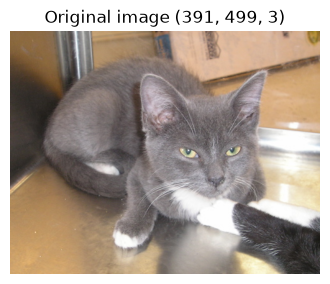

In [10]:
plt.figure(figsize=(4, 4))
plt.imshow(image_rgb)
plt.title(f"Original image {image_rgb.shape}")
plt.axis("off")
plt.show()

In [11]:
def show_images(images, titles, cmap=None, columns=None):
    """Display a row (or grid) of images side by side."""
    columns = columns or len(images)
    rows = int(np.ceil(len(images) / columns))
    
    plt.figure(figsize=(4 * columns, 4 * rows))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, columns, i + 1)
        plt.imshow(image, cmap=cmap)
        plt.title(title, fontsize=11)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

In [12]:
for path in image_paths[:6]:
    shape = cv2.imread(path).shape
    print(f"{shape}  {os.path.basename(path)}")

(391, 499, 3)  10054.jpg
(388, 427, 3)  10067.jpg
(216, 216, 3)  10079.jpg
(375, 500, 3)  10104.jpg
(375, 500, 3)  10148.jpg
(375, 500, 3)  1019.jpg


In [13]:
IMAGE_SIZE = 224

resized_image = cv2.resize(image_rgb, (IMAGE_SIZE, IMAGE_SIZE))

print("Original shape: ", image_rgb.shape)
print("Resized shape: ", resized_image.shape)


Original shape:  (391, 499, 3)
Resized shape:  (224, 224, 3)


In [14]:
scaled_image = image_rgb.astype(np.float32)/255.0

print("Before Scaling:", image_rgb.dtype)
print("After Scaling:", scaled_image.dtype)


Before Scaling: uint8
After Scaling: float32


## normalized = (value - mean )/std

In [15]:

normalized_image = (scaled_image - 0.5)/0.5
print("Scaled Image:", scaled_image.min(), scaled_image.max())
print("Normalized Image:", normalized_image.min(), normalized_image.max())


Scaled Image: 0.07450981 1.0
Normalized Image: -0.8509804 1.0


In [16]:
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

tensor_image = to_tensor(image_rgb)
normalized_tensor = normalize(tensor_image)

print("to tensor Image:", tensor_image.min(), tensor_image.max())
print("Normalized Image:", normalized_tensor.min(), normalized_tensor.max())

to tensor Image: tensor(0.0745) tensor(1.)
Normalized Image: tensor(-0.8510) tensor(1.)


Grayscale shape : (391, 499) (no colour channel anymore)
Binary values   : [  0 255]
white pixels    : 57.5%


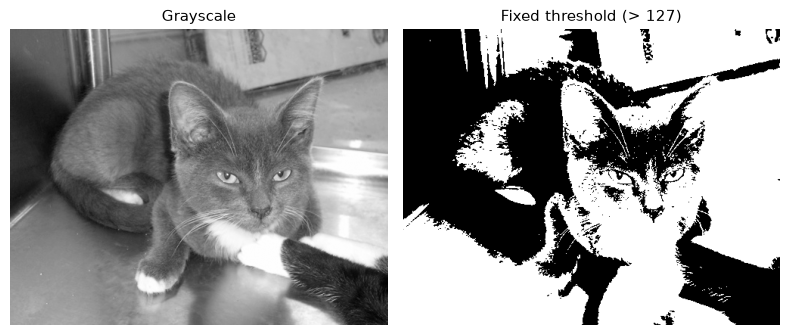

In [17]:
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

THRESHOLD_VALUE = 127
_, binary_fixed = cv2.threshold(gray_image, THRESHOLD_VALUE, 255, cv2.THRESH_BINARY)

white_share = 100 * np.count_nonzero(binary_fixed) / binary_fixed.size

print("Grayscale shape :", gray_image.shape, "(no colour channel anymore)")
print("Binary values   :", np.unique(binary_fixed))
print(f"white pixels    : {white_share:.1f}%")

show_images(
    [gray_image, binary_fixed],
    ["Grayscale", f"Fixed threshold (> {THRESHOLD_VALUE})"],
    cmap="gray",
)

Fixed threshold : 127
Otsu threshold  : 142  <- chosen from this image


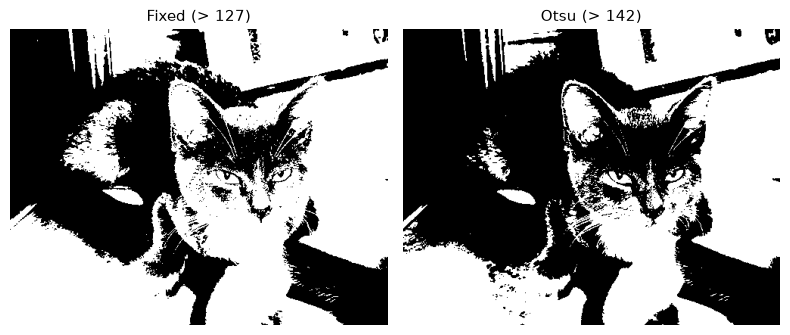

In [18]:
otsu_value, binary_image = cv2.threshold(
    gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Fixed threshold : {THRESHOLD_VALUE}")
print(f"Otsu threshold  : {otsu_value:.0f}  <- chosen from this image")

show_images(
    [binary_fixed, binary_image],
    [f"Fixed (> {THRESHOLD_VALUE})", f"Otsu (> {otsu_value:.0f})"],
    cmap="gray",
)

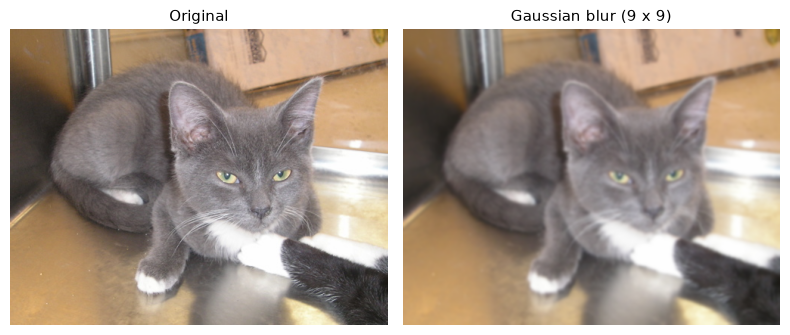

In [19]:
blurred_image = cv2.GaussianBlur(image_rgb, (9, 9), sigmaX=0)

show_images(
    [image_rgb, blurred_image],
    ["Original", "Gaussian blur (9 x 9)"],
)


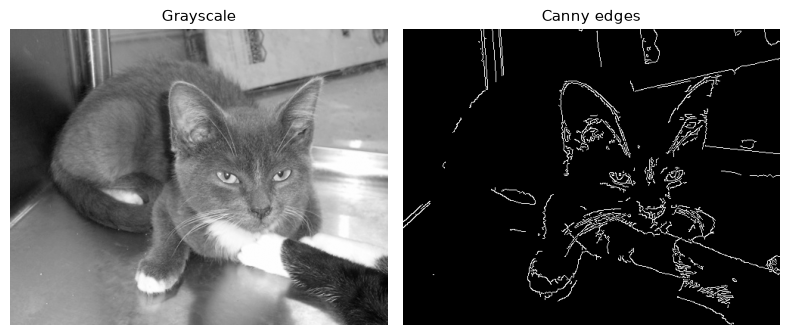

In [20]:
edges = cv2.Canny(gray_image, threshold1=100, threshold2=200)

show_images(
    [gray_image, edges],
    ["Grayscale", "Canny edges"],
    cmap="gray",
)


Contours Found           : 40
Longer than 100 pixels : 13

 contour 0:   89 points, length = 371 px
 contour 1:  190 points, length = 345 px
 contour 2:  139 points, length = 313 px
 contour 3:   92 points, length = 255 px
 contour 4:   92 points, length = 178 px


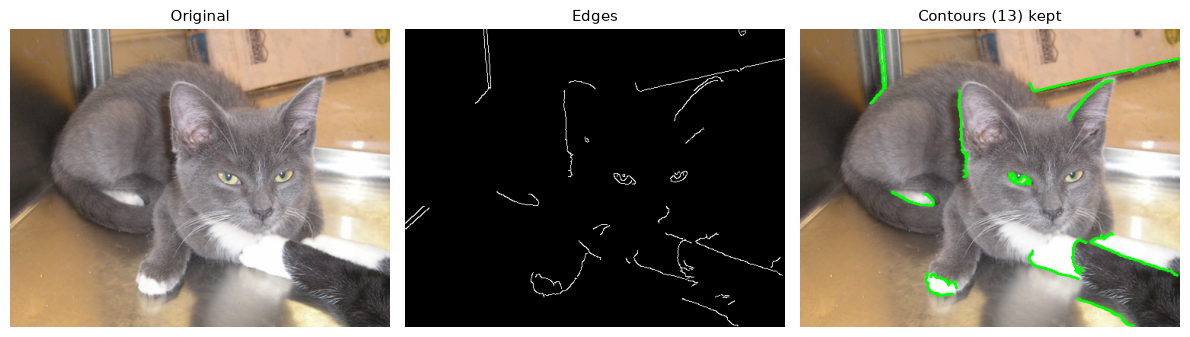

In [21]:
blurred_gray = cv2.GaussianBlur(gray_image, (5, 5), sigmaX=0)
contour_edges = cv2.Canny(blurred_gray, threshold1=100, threshold2=200)

contours, _ = cv2.findContours(contour_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

MIN_CONTOUR_LENGTH = 100  # pixels

long_contours = [c for c in contours if cv2.arcLength(c, False) >= MIN_CONTOUR_LENGTH]

# Draw on a copy so the original image stays untouched.
contour_image = image_rgb.copy()
cv2.drawContours(contour_image, long_contours, -1, (0, 255, 0), thickness=2)

print("Contours Found           :", len(contours))
print(f"Longer than {MIN_CONTOUR_LENGTH} pixels :", len(long_contours))
print()
for i, contour in enumerate(sorted(long_contours, key=lambda c: cv2.arcLength(c, False), reverse=True)[:5]):
    print(f" contour {i}: {len(contour):>4} points, length = {cv2.arcLength(contour, False):.0f} px")

show_images(
    [image_rgb, cv2.cvtColor(contour_edges, cv2.COLOR_GRAY2RGB), contour_image],
    ["Original", "Edges", f"Contours ({len(long_contours)}) kept"]
)

Binary image shape : (391, 499)
Kernel shape       : (5, 5)
Foreground         : 46.1% of all pixels


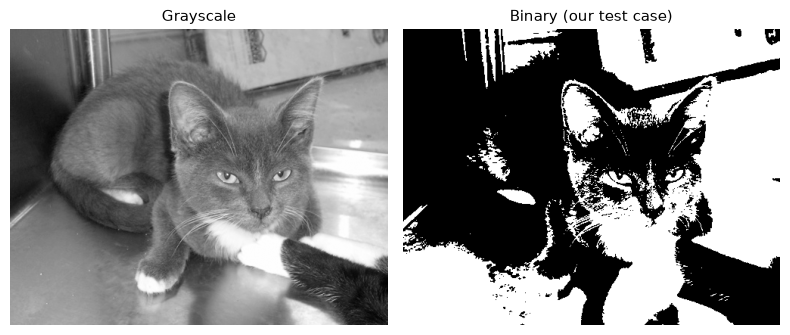

In [22]:
kernel = np.ones((5, 5), np.uint8)

def foreground_percent(binary):
    """Share of white (foreground) pixels - a simple number to watch as we shrink/grow."""
    return 100 * np.count_nonzero(binary) / binary.size

print("Binary image shape :", binary_image.shape)
print("Kernel shape       :", kernel.shape)
print(f"Foreground         : {foreground_percent(binary_image):.1f}% of all pixels")

show_images([gray_image, binary_image], ["Grayscale", "Binary (our test case)"], cmap="gray")


Foreground before : 46.1%
Foreground after  : 36.2%


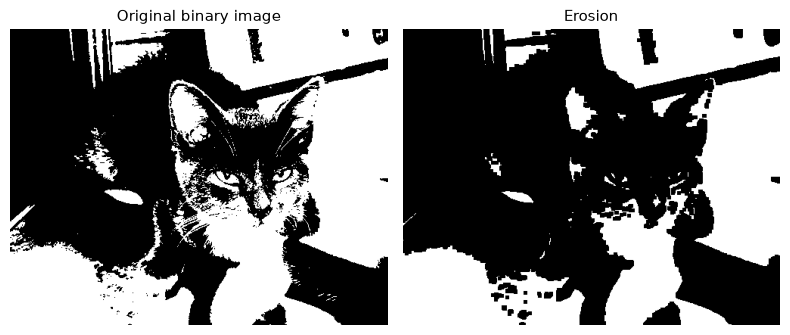

In [23]:
erosion = cv2.erode(binary_image, kernel, iterations=1)

print(f"Foreground before : {foreground_percent(binary_image):.1f}%")
print(f"Foreground after  : {foreground_percent(erosion):.1f}%")

show_images(
    [binary_image, erosion],
    ["Original binary image", "Erosion"],
    cmap="gray",
)

Foreground before : 46.1%
Foreground after  : 57.3%


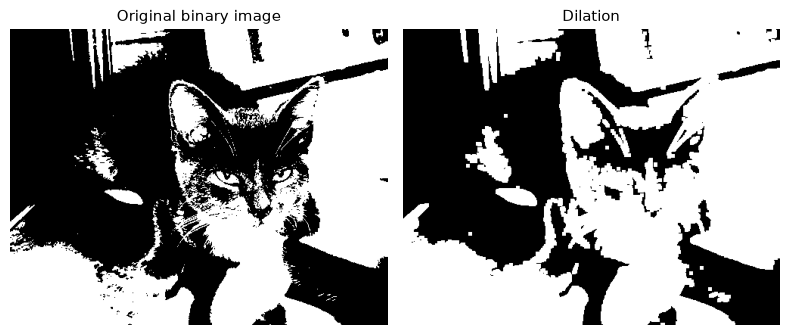

In [24]:
dilation = cv2.dilate(binary_image, kernel, iterations=1)

print(f"Foreground before : {foreground_percent(binary_image):.1f}%")
print(f"Foreground after  : {foreground_percent(dilation):.1f}%")

show_images(
    [binary_image, dilation],
    ["Original binary image", "Dilation"],
    cmap="gray",
)

Original : 46.1%
Erosion  : 36.2%   <- shrank a lot
Opening  : 42.2%   <- noise gone, size mostly restored


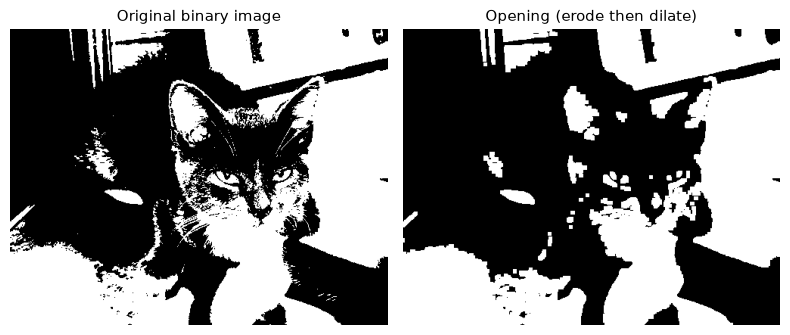

In [25]:

opening = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)

print(f"Original : {foreground_percent(binary_image):.1f}%")
print(f"Erosion  : {foreground_percent(erosion):.1f}%   <- shrank a lot")
print(f"Opening  : {foreground_percent(opening):.1f}%   <- noise gone, size mostly restored")

show_images(
    [binary_image, opening],
    ["Original binary image", "Opening (erode then dilate)"],
    cmap="gray",
)


Original : 46.1%
Dilation : 57.3%   <- grew a lot
Closing  : 49.8%   <- holes filled, size mostly restored


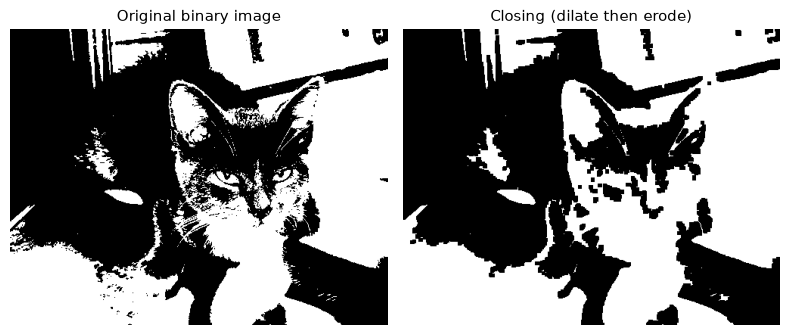

In [26]:
closing = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

print(f"Original : {foreground_percent(binary_image):.1f}%")
print(f"Dilation : {foreground_percent(dilation):.1f}%   <- grew a lot")
print(f"Closing  : {foreground_percent(closing):.1f}%   <- holes filled, size mostly restored")

show_images(
    [binary_image, closing],
    ["Original binary image", "Closing (dilate then erode)"],
    cmap="gray",
)


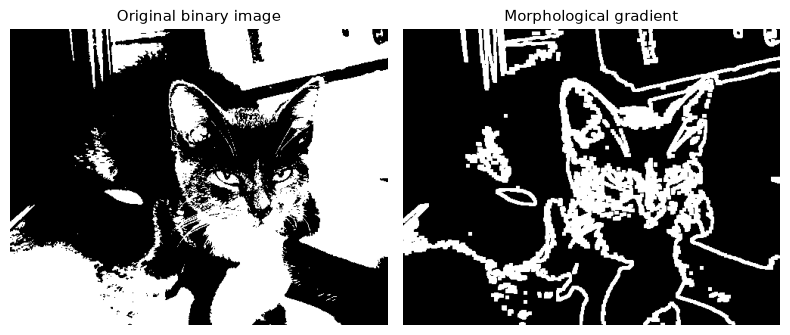

In [27]:
gradient = cv2.morphologyEx(binary_image, cv2.MORPH_GRADIENT, kernel)

show_images(
    [binary_image, gradient],
    ["Original binary image", "Morphological gradient"],
    cmap="gray",
)

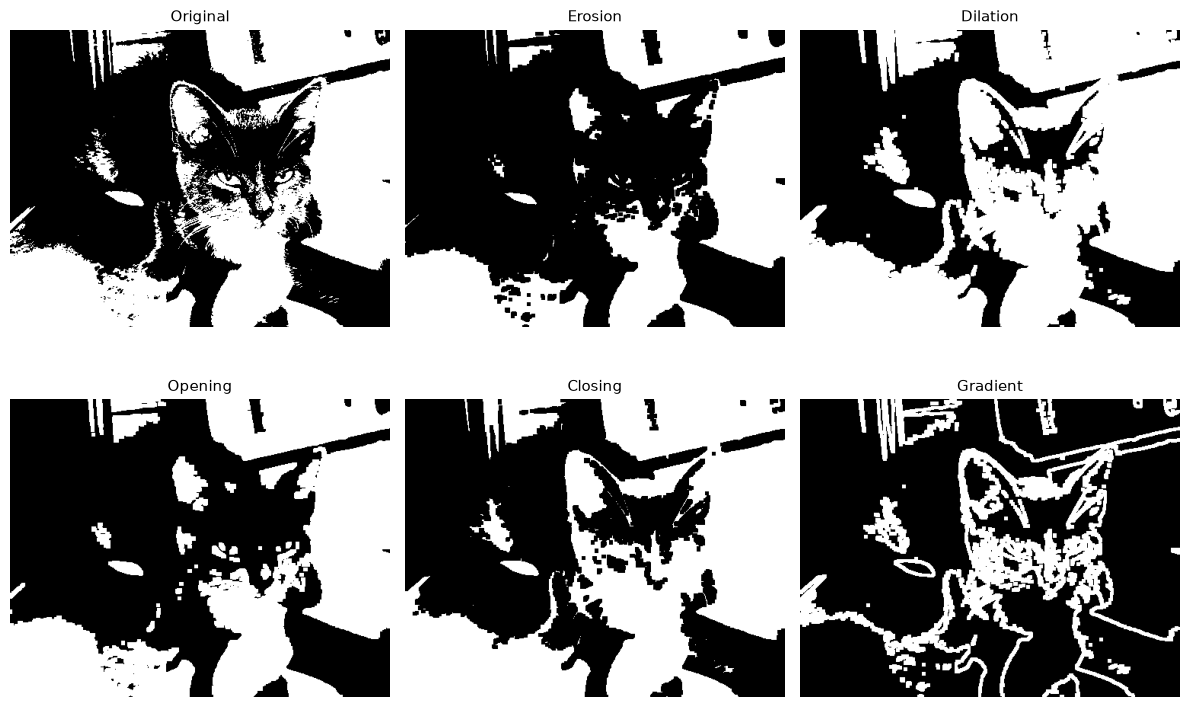

In [28]:
show_images(
    [binary_image, erosion, dilation, opening, closing, gradient],
    ["Original", "Erosion", "Dilation", "Opening", "Closing", "Gradient"],
    cmap="gray",
    columns=3
)

## 7. Making Training Data More Diverse

In [29]:
augmentation_transforms = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ]
)

print(augmentation_transforms)

Compose(
    ToPILImage()
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
)


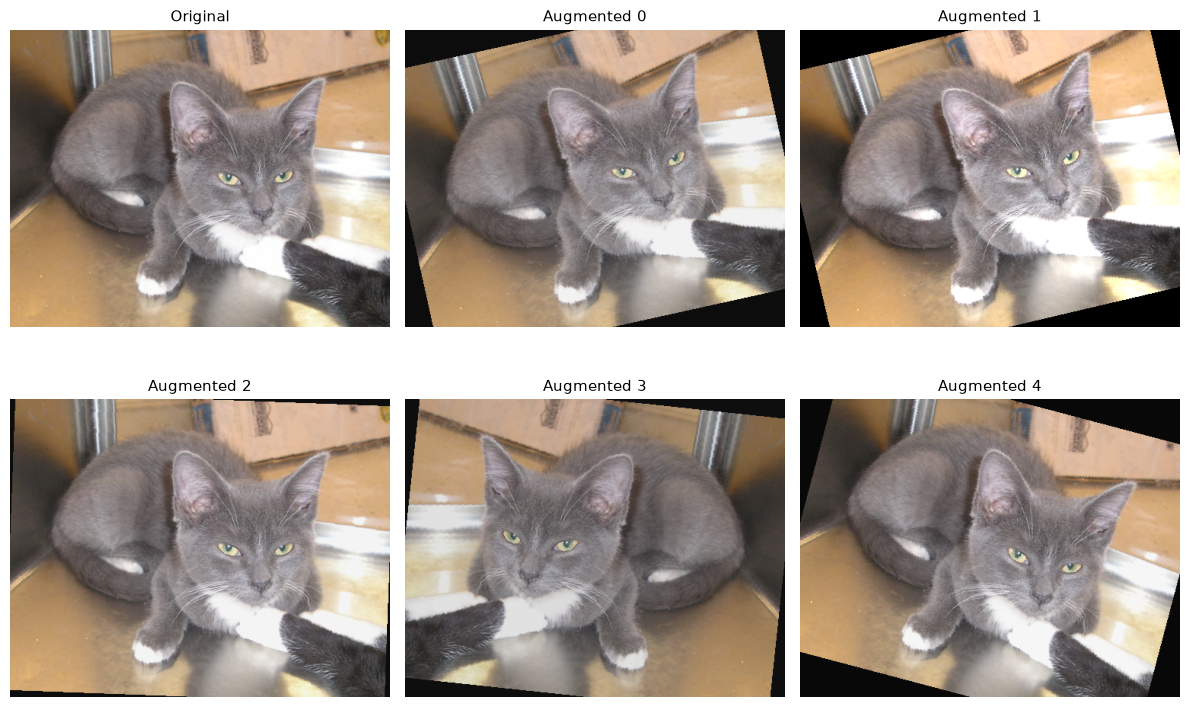

In [30]:
def tensor_to_image(tensor):
    return tensor.permute(1, 2, 0).numpy()

augmented_versions = [
    tensor_to_image(augmentation_transforms(image_rgb)) for _ in range(5)
]

show_images(
    [image_rgb] + augmented_versions,
    ["Original"] + [f"Augmented {i}" for i in range(5)],
    columns=3,
)


### 8. Dataset Inspection

In [31]:
# تعريف الدالة أولاً لتجنب أي خطأ
def class_name_to_index(class_name):
    return class_names.index(class_name)


label_array = np.array(labels)

print("Classes      :", class_names)
print("Total images:", len(image_paths))
print()
for class_name in class_names:
    count = int(np.sum(label_array == class_name_to_index(class_name)))
    percentage = 100 * count / len(labels)
    print(f" {class_name:<12} {count:>5} images ({percentage:5.1f}%)")



Classes      : ['Cat', 'Dog']
Total images: 1000

 Cat            500 images ( 50.0%)
 Dog            500 images ( 50.0%)


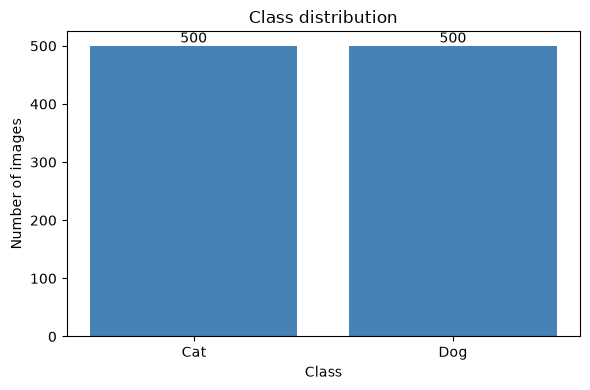

In [32]:
counts = [int(np.sum(label_array == index)) for index in range(len(class_names))]

plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, counts, color="steelblue")
plt.bar_label(bars)
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()


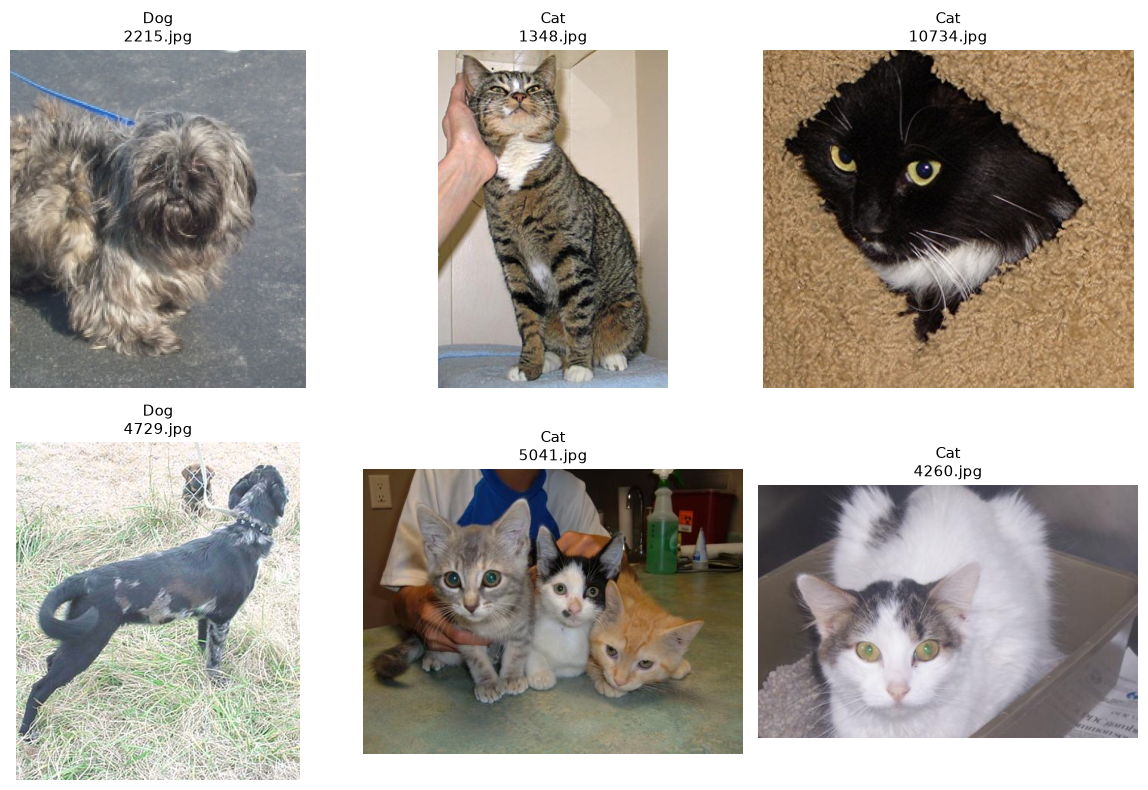

In [33]:
random_indices = random.sample(
    range(len(image_paths)), k=min(6, len(image_paths))
)

sample_images = []
sample_titles = []
for index in random_indices:
  image = cv2.imread(image_paths[index])
  sample_images.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  sample_titles.append(
      f"{class_names[labels[index]]}\n{os.path.basename(image_paths[index])}"
  )

show_images(sample_images, sample_titles, columns=3)


## 8.2class imbalance 

## 9. Train / Validation / Test Split

In [34]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15  # whatever is left over


def split_dataset(image_paths, labels, train_ratio, val_ratio, seed=SEED):
  """Shuffle the examples once and cut them into three groups."""
  indices = np.arange(len(image_paths))

  rng = np.random.default_rng(seed)
  rng.shuffle(indices)

  n_total = len(indices)
  n_train = int(train_ratio * n_total)
  n_val = int(val_ratio * n_total)

  train_indices = indices[:n_train]
  val_indices = indices[n_train : n_train + n_val]
  test_indices = indices[n_train + n_val :]

  def take(selected):
    return ([image_paths[i] for i in selected], [labels[i] for i in selected])

  return take(train_indices), take(val_indices), take(test_indices)


(train_paths, train_labels), (val_paths, val_labels), (
    test_paths,
    test_labels,
) = split_dataset(image_paths, labels, TRAIN_RATIO, VAL_RATIO)

print("Total images  :", len(image_paths))
print()
print(
    f"Train images  : {len(train_paths):>4}"
    f" ({100 * len(train_paths) / len(image_paths):.1f}%)"
)
print(
    f"Validation images: {len(val_paths):>4}"
    f" ({100 * len(val_paths) / len(image_paths):.1f}%)"
)
print(
    f"Test images   : {len(test_paths):>4}"
    f" ({100 * len(test_paths) / len(image_paths):.1f}%)"
)

Total images  : 1000

Train images  :  700 (70.0%)
Validation images:  150 (15.0%)
Test images   :  150 (15.0%)


In [35]:
print(f"{'split':<12}" + "".join(f"{name:>12}" for name in class_names))
for split_name, split_labels in (("train", train_labels), ("val", val_labels), ("test", test_labels)):
    row = [int(np.sum(np.array(split_labels) == index)) for index in range(len(class_names))]
    print(f"{split_name:<12}" + "".join(f"{count:>12}" for count in row))


split                Cat         Dog
train                346         354
val                   86          64
test                  68          82


## 10. Understanding Data Leakage

In [36]:
# WRONG on purpose: each split is drawn from the full dataset independently.
rng = np.random.default_rng(SEED)

leaky_train = [image_paths[i] for i in rng.choice(len(image_paths), size=int(0.70 * len(image_paths)), replace=False)]
leaky_test = [image_paths[i] for i in rng.choice(len(image_paths), size=int(0.15 * len(image_paths)), replace=False)]

overlap = set(leaky_train) & set(leaky_test)

print("Leaky train size :", len(leaky_train))
print("Leaky test size  :", len(leaky_test))
print("Images in BOTH   :", len(overlap))
print()
for path in list(overlap)[:3]:
    print(" leaked:", path)


Leaky train size : 700
Leaky test size  : 150
Images in BOTH   : 109

 leaked: data\Dog\8715.jpg
 leaked: data\Dog\8547.jpg
 leaked: data\Dog\4442.jpg


In [37]:
train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

print("Images in both train and val :", len(train_set & val_set))
print("Images in both train and test :", len(train_set & test_set))
print("Images in both val and test :", len(val_set & test_set))
print()

no_overlap = not (train_set & val_set or train_set & test_set or val_set & test_set)
all_accounted_for = len(train_set | val_set | test_set) == len(set(image_paths))

print("No overlap between splits :", no_overlap)
print("Every image used exactly once:", all_accounted_for)


Images in both train and val : 0
Images in both train and test : 0
Images in both val and test : 0

No overlap between splits : True
Every image used exactly once: True


## 11. Building a Custom PyTorch Dataset

In [38]:
class CustomImageDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]

        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = self.labels[index]

        return image, label


## 12. Preprocessing vs Augmentation

In [39]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print("TRAIN transform")
print(train_transform)
print()
print("VALIDATION / TEST transform")
print(eval_transform)


TRAIN transform
Compose(
    ToPILImage()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

VALIDATION / TEST transform
Compose(
    ToPILImage()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## 13. Create the Datasets

In [40]:
train_dataset = CustomImageDataset(train_paths, train_labels, transform=train_transform)
val_dataset = CustomImageDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = CustomImageDataset(test_paths, test_labels, transform=eval_transform)

print("Train dataset size      :", len(train_dataset))
print("Validation dataset size :", len(val_dataset))
print("Test dataset size       :", len(test_dataset))


Train dataset size      : 700
Validation dataset size : 150
Test dataset size       : 150


In [41]:
image, label = train_dataset[0]

print("Image type  :", type(image))
print("Image dtype :", image.dtype)
print("Image shape :", tuple(image.shape))
print("Value range : [{:.2f}, {:.2f}]".format(image.min(), image.max()))
print()
print("Label       :", label, "-", class_names[label])


Image type  : <class 'torch.Tensor'>
Image dtype : torch.float32
Image shape : (3, 224, 224)
Value range : [-0.98, 0.81]

Label       : 1 - Dog


In [42]:
train_a, _ = train_dataset[0]
train_b, _ = train_dataset[0]

val_a, _ = val_dataset[0]
val_b, _ = val_dataset[0]

print("Train: same index twice -> Identical tensors?", torch.equal(train_a, train_b))
print("Val  : same index twice -> Identical tensors?", torch.equal(val_a, val_b))


Train: same index twice -> Identical tensors? False
Val  : same index twice -> Identical tensors? True


## 14. Understanding the DataLoader

In [43]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train     : {len(train_dataset):>4} images -> {len(train_loader):>3} batches")
print(f"Validation: {len(val_dataset):>4} images -> {len(val_loader):>3} batches")
print(f"Test      : {len(test_dataset):>4} images -> {len(test_loader):>3} batches")


Train     :  700 images ->  22 batches
Validation:  150 images ->   5 batches
Test      :  150 images ->   5 batches


## 15. Inspect a Batch

In [44]:

images, labels_batch = next(iter(train_loader))

print("Images:", tuple(images.shape))
print("Labels:", tuple(labels_batch.shape))
print()
print("Images dtype:", images.dtype)
print("Labels dtype:", labels_batch.dtype)
print()
print("Labels in this batch:", labels_batch.tolist())


Images: (32, 3, 224, 224)
Labels: (32,)

Images dtype: torch.float32
Labels dtype: torch.int64

Labels in this batch: [1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1]


normalization = (value-mean)/std

value-mean = normalization * std

value = normalization * std +mean


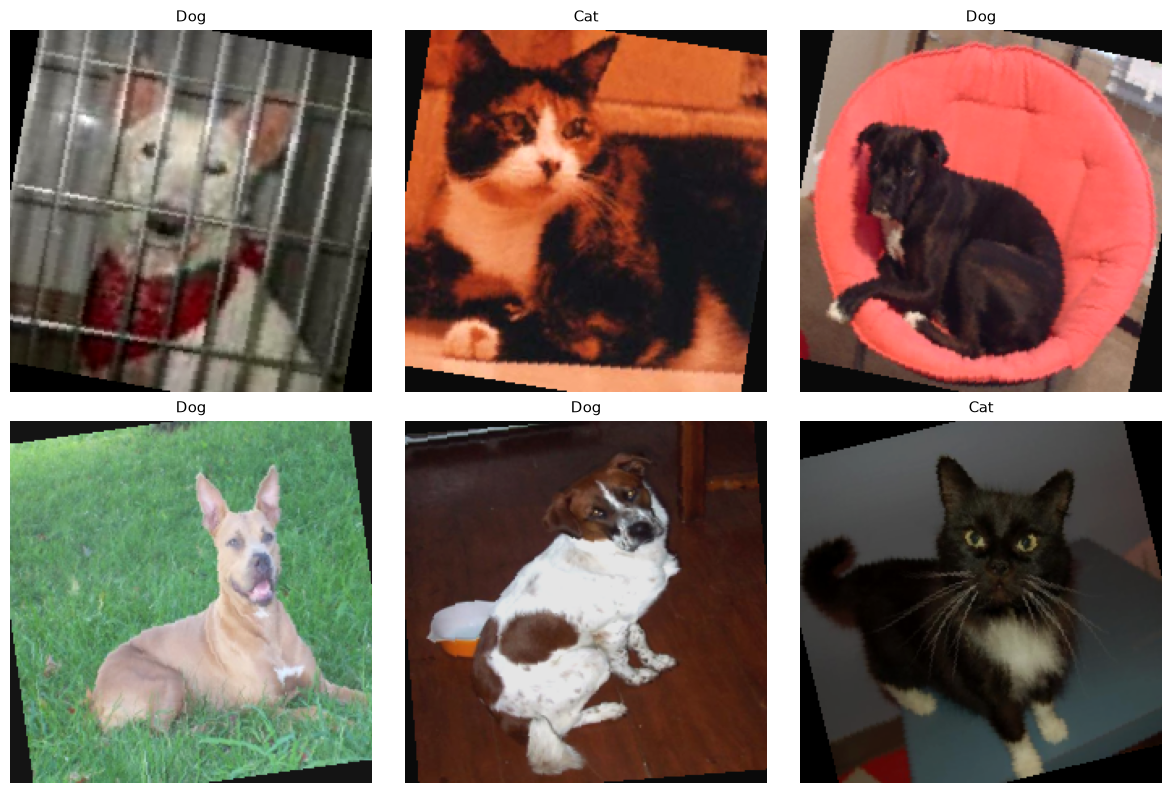

In [45]:
MEAN = np.array([0.5, 0.5, 0.5])
STD = np.array([0.5, 0.5, 0.5])

def denormalize(tensor):
    """Turn a normalized C x H x W tensor back into a displayable H x W x C image."""
    image = tensor.permute(1, 2, 0).numpy() # C, H, W -> H, W, C
    image = image * STD + MEAN              # undo the normalization
    return np.clip(image, 0, 1)             # remove tiny rounding errors outside [0, 1]

batch_images = [denormalize(images[i]) for i in range(6)]
batch_titles = [class_names[labels_batch[i]] for i in range(6)]

show_images(batch_images, batch_titles, columns=3)


## Our Image Data Pipeline

In [46]:
print("PIPELINE CHECK")
print("-" * 40)
print(f"Classes                 : {class_names}")
print(f"Usable images           : {len(image_paths)}")
print(f"Broken files found      : {len(empty_files) + len(broken_paths)}")
print(f"Train / Val / Test      : {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")
print(f"No split overlap        : {no_overlap}")
print(f"Batch size              : {BATCH_SIZE}")
print(f"Batch tensor shape      : {tuple(images.shape)}")
print(f"Label tensor shape      : {tuple(labels_batch.shape)}")
print("-" * 40)
print("Ready for a model.")


PIPELINE CHECK
----------------------------------------
Classes                 : ['Cat', 'Dog']
Usable images           : 1000
Broken files found      : 0
Train / Val / Test      : 700 / 150 / 150
No split overlap        : True
Batch size              : 32
Batch tensor shape      : (32, 3, 224, 224)
Label tensor shape      : (32,)
----------------------------------------
Ready for a model.
